In [41]:
import yt
import re
import os
import subprocess
from PIL import Image
import astropy.units as u
import astropy.constants as c
import numpy as np

In [36]:
freq_low, freq_high = 3.29e15, 1.50e16
avg_freq = (freq_low + freq_high) * 0.5 * u.Hz
L = 1e32 * u.erg / u.s
hplanck = Constants.hplanck * u.erg * u.s
quanta_energy = (hplanck * avg_freq).to(u.erg)
Q = L / quanta_energy
n_H = 1.0e10 * u.cm**(-3)
alpha_B = 2.6e-13 * u.cm**3 / u.s
r_s = (3 * Q / (4 * np.pi * n_H**2 * alpha_B))**(1/3)
t_rec = 1 / (n_H * alpha_B)
r_s.to(u.Rsun), t_rec.to(u.s), Q

(<Quantity 3.55694741 solRad>,
 <Quantity 384.61538462 s>,
 <Quantity 1.65029012e+42 1 / s>)

In [79]:
class Constants:
    m_p = 1.67353251819e-24
    m_e = 9.10938188e-28
    hplanck = 6.62606957e-27

def e_density(field, data):
    return data['scalar_0'] / Constants.m_e

def HI_density(field, data):
    return data['scalar_1'] / Constants.m_p

def HII_density(field, data):
    return data['scalar_2'] / Constants.m_p

def photon_density(field, data):
    freq_low, freq_high = 3.29e15, 1.50e16
    avg_freq = (freq_low + freq_high) / 2
    return data['radEnergy-Group0'] / (Constants.hplanck * avg_freq)

def x_HI(field, data):
    n_HI = data['scalar_1'] / Constants.m_p
    n_HII = data['scalar_2'] / Constants.m_p
    return n_HI / (n_HI + n_HII)

In [80]:
def create_movie(files, outdir, outname, framerate=5):
    outpath = os.path.join(outdir, f'{outname}.mp4')
    ffmpeg_cmd = [
        'ffmpeg',
        '-y',  # overwrite
        '-f', 'image2pipe',
        '-vcodec', 'png',
        '-framerate', str(framerate),
        '-i', '-',  # input from stdin
        outpath
    ]
    process = subprocess.Popen(ffmpeg_cmd, stdin=subprocess.PIPE)
    # Feed images to ffmpeg
    for file in files:
        img = Image.open(file).convert("RGB")  # convert to RGB just in case
        img.save(process.stdin, format='PNG')
    process.stdin.close()
    process.wait()
    print(f"Movie saved to {outpath}")

In [81]:
class StromgenSphereSnapshot:
    def __init__(self, path, outdir=None):
        self.path = path
        self.outdir = outdir
        self.ds = yt.load(path)
        self.ds.add_field(("boxlib", "n_e"), function=e_density, units="dimensionless", sampling_type="cell")
        self.ds.add_field(("boxlib", "n_HI"), function=HI_density, units="dimensionless", sampling_type="cell")
        self.ds.add_field(("boxlib", "n_HII"), function=HII_density, units="dimensionless", sampling_type="cell")
        self.ds.add_field(("boxlib", "n_photon"), function=photon_density, units="dimensionless", sampling_type="cell")
        self.ds.add_field(("boxlib", "x_HI"), function=x_HI, units="dimensionless", sampling_type="cell")
        self.ad = self.ds.all_data()
        if self.outdir is None:
            self.outdir = os.path.join(self.path, "plots")
        os.makedirs(self.outdir, exist_ok=True)

    def get_quantity_range(self, field_name):
        field_data = self.ad[field_name]
        vmin, vmax = np.min(field_data), np.max(field_data)
        return vmin, vmax

    def create_quantity_map(self, field_name, vmin=None, vmax=None, cmap="viridis", redo=False):
        outpath = os.path.join(self.outdir, f"{field_name}.png")
        if os.path.exists(outpath) and not redo:
            return outpath
        plot = yt.SlicePlot(self.ds, "z", field_name)
        plot.set_zlim(field_name, zmin=vmin, zmax=vmax)
        plot.set_cmap(field_name, cmap)
        plot.set_colorbar_label(field_name, field_name)
        plot.save(outpath)
        return outpath

    def create_radiation_map(self, vmin=None, vmax=None, cmap="viridis", redo=False):
        outpath = self.create_quantity_map("n_photon", vmin=vmin, vmax=vmax, cmap=cmap, redo=redo)
        return outpath
    
    def create_scalar0_map(self, vmin=None, vmax=None, cmap="viridis", redo=False):
        outpath = self.create_quantity_map("n_e", vmin=vmin, vmax=vmax, cmap=cmap, redo=redo)
        return outpath
    
    def create_scalar1_map(self, vmin=None, vmax=None, cmap="viridis", redo=False):
        outpath = self.create_quantity_map("n_HI", vmin=vmin, vmax=vmax, cmap=cmap, redo=redo)
        return outpath
    
    def create_scalar2_map(self, vmin=None, vmax=None, cmap="viridis", redo=False):
        outpath = self.create_quantity_map("n_HII", vmin=vmin, vmax=vmax, cmap=cmap, redo=redo)
        return outpath
    
    def create_x_HI_map(self, vmin=None, vmax=None, cmap="viridis", redo=False):
        outpath = self.create_quantity_map("x_HI", vmin=vmin, vmax=vmax, cmap=cmap, redo=redo)
        return outpath

    def create_density_map(self, vmin=None, vmax=None, cmap="viridis", redo=False):
        outpath = self.create_quantity_map("gasDensity", vmin=vmin, vmax=vmax, cmap=cmap, redo=redo)
        return outpath

class StromgenSphere:
    def __init__(self, path, outdir=None, start_pattern="plt", ending_number=None, step=1):
        self.path = path
        self.outdir = outdir
        self.start_pattern = start_pattern
        self.ending_number = ending_number
        self.step = step
        if self.outdir is None:
            self.outdir = os.path.join(self.path, "Plots")
        os.makedirs(self.outdir, exist_ok=True)
        self.plotfile_pathlist = self.get_plotfile_pathlist()
        self.snapshot_list = [StromgenSphereSnapshot(plotfile_path) for plotfile_path in self.plotfile_pathlist]

    def get_plotfile_pathlist(self):
        files = [f for f in os.listdir(self.path) if re.match(f"{self.start_pattern}\d+", f)]
        files.sort(key=lambda x: int(re.findall(r'\d+', x)[0]))
        if self.ending_number is not None:
            files = [f for f in files if int(re.findall(r'\d+', f)[0]) <= self.ending_number]
        files = files[::self.step]
        return [os.path.join(self.path, f) for f in files]
    
    def get_quantity_range(self, field_name):
        vmin, vmax = None, None
        for snapshot in self.snapshot_list:
            snapshot_vmin, snapshot_vmax = snapshot.get_quantity_range(field_name)
            if vmin is None:
                vmin, vmax = snapshot_vmin, snapshot_vmax
            else:
                vmin = min(vmin, snapshot_vmin)
                vmax = max(vmax, snapshot_vmax)
        return vmin, vmax
    
    def create_quantity_plots(self, field_name, vmin=None, vmax=None, cmap="viridis", redo=False):
        plot_paths = []
        qty_range = self.get_quantity_range(field_name)
        if vmin is None:
            vmin = qty_range[0]
        if vmax is None:
            vmax = qty_range[1]
        for snapshot in self.snapshot_list:
            plot_paths.append(snapshot.create_quantity_map(field_name, vmin=vmin, vmax=vmax, cmap=cmap, redo=redo))
        return plot_paths

    def create_radiation_plots(self, vmin=None, vmax=None, cmap="viridis", redo=False):
        return self.create_quantity_plots("n_photon", vmin=vmin, vmax=vmax, cmap=cmap, redo=redo)
    
    def create_scalar0_plots(self, vmin=None, vmax=None, cmap="viridis", redo=False):
        return self.create_quantity_plots("n_e", vmin=vmin, vmax=vmax, cmap=cmap, redo=redo)
    
    def create_scalar1_plots(self, vmin=None, vmax=None, cmap="viridis", redo=False):
        return self.create_quantity_plots("n_HI", vmin=vmin, vmax=vmax, cmap=cmap, redo=redo)
    
    def create_scalar2_plots(self, vmin=None, vmax=None, cmap="viridis", redo=False):
        return self.create_quantity_plots("n_HII", vmin=vmin, vmax=vmax, cmap=cmap, redo=redo)
    
    def create_x_HI_plots(self, vmin=None, vmax=None, cmap="viridis", redo=False):
        return self.create_quantity_plots("x_HI", vmin=vmin, vmax=vmax, cmap=cmap, redo=redo)
    
    def create_density_plots(self, vmin=None, vmax=None, cmap="viridis", redo=False):
        return self.create_quantity_plots("gasDensity", vmin=vmin, vmax=vmax, cmap=cmap, redo=redo)
    
    def create_radiation_video(self, output_filename="radiation_evolution.mp4", fps=10, vmin=None, vmax=None, cmap="viridis", redo=False):
        radiation_plot_paths = self.create_radiation_plots(vmin=vmin, vmax=vmax, cmap=cmap, redo=redo)
        create_movie(radiation_plot_paths, self.outdir, output_filename, framerate=fps)

    def create_scalar_videos(self, output_filename_prefix="scalar_evolution", fps=10, vmin=None, vmax=None, cmap="viridis", redo=False):
        scalar_plot0_paths = self.create_scalar0_plots(vmin=vmin, vmax=vmax, cmap=cmap, redo=redo)
        scalar_plot1_paths = self.create_scalar1_plots(vmin=vmin, vmax=vmax, cmap=cmap, redo=redo)
        scalar_plot2_paths = self.create_scalar2_plots(vmin=vmin, vmax=vmax, cmap=cmap, redo=redo)
        create_movie(scalar_plot0_paths, self.outdir, f"{output_filename_prefix}_0.mp4", framerate=fps)
        create_movie(scalar_plot1_paths, self.outdir, f"{output_filename_prefix}_1.mp4", framerate=fps)
        create_movie(scalar_plot2_paths, self.outdir, f"{output_filename_prefix}_2.mp4", framerate=fps)

    def create_x_HI_video(self, output_filename="x_HI_evolution.mp4", framerate=5, vmin=None, vmax=None, cmap="viridis", redo=False):
        x_HI_plot_paths = self.create_x_HI_plots(vmin=vmin, vmax=vmax, cmap=cmap, redo=redo)
        create_movie(x_HI_plot_paths, self.outdir, output_filename, framerate=framerate)

    def create_density_video(self, output_filename="density_evolution.mp4", framerate=5, vmin=None, vmax=None, cmap="viridis", redo=False):
        density_plot_paths = self.create_density_plots(vmin=vmin, vmax=vmax, cmap=cmap, redo=redo)
        create_movie(density_plot_paths, self.outdir, output_filename, framerate=framerate)

In [104]:
ds_temp.field_list

[('boxlib', 'gasDensity'),
 ('boxlib', 'gasEnergy'),
 ('boxlib', 'gasInternalEnergy'),
 ('boxlib', 'radEnergy-Group0'),
 ('boxlib', 'scalar_0'),
 ('boxlib', 'scalar_1'),
 ('boxlib', 'scalar_2'),
 ('boxlib', 'x-GasMomentum'),
 ('boxlib', 'x-RadFlux-Group0'),
 ('boxlib', 'y-GasMomentum'),
 ('boxlib', 'y-RadFlux-Group0'),
 ('boxlib', 'z-GasMomentum'),
 ('boxlib', 'z-RadFlux-Group0')]

In [113]:
(5e27*u.cm/16).to(u.Gpc)

<Quantity 0.10127435 Gpc>

In [111]:
((500 * u.Myr).to(u.s) * 3e10 * u.cm/u.s).to(u.Gpc)

<Quantity 0.15340682 Gpc>

In [108]:
5e26/3e10

1.6666666666666666e+16

In [107]:
(200000000000000 * 3e10 * u.cm).to(u.Gpc)

<Quantity 0.00194447 Gpc>

yt : [INFO     ] 2026-03-02 19:56:04,415 Parameters: current_time              = 200000000000000.0
yt : [INFO     ] 2026-03-02 19:56:04,416 Parameters: domain_dimensions         = [16 16 16]
yt : [INFO     ] 2026-03-02 19:56:04,416 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2026-03-02 19:56:04,417 Parameters: domain_right_edge         = [5.e+27 5.e+27 5.e+27]
yt : [INFO     ] 2026-03-02 19:56:04,466 xlim = 0.000000 4999999999999999791559868416.000000
yt : [INFO     ] 2026-03-02 19:56:04,466 ylim = 0.000000 4999999999999999791559868416.000000
yt : [INFO     ] 2026-03-02 19:56:04,467 xlim = 0.000000 4999999999999999791559868416.000000
yt : [INFO     ] 2026-03-02 19:56:04,468 ylim = 0.000000 4999999999999999791559868416.000000
yt : [INFO     ] 2026-03-02 19:56:04,468 Making a fixed resolution buffer of (('boxlib', 'radEnergy-Group0')) 800 by 800



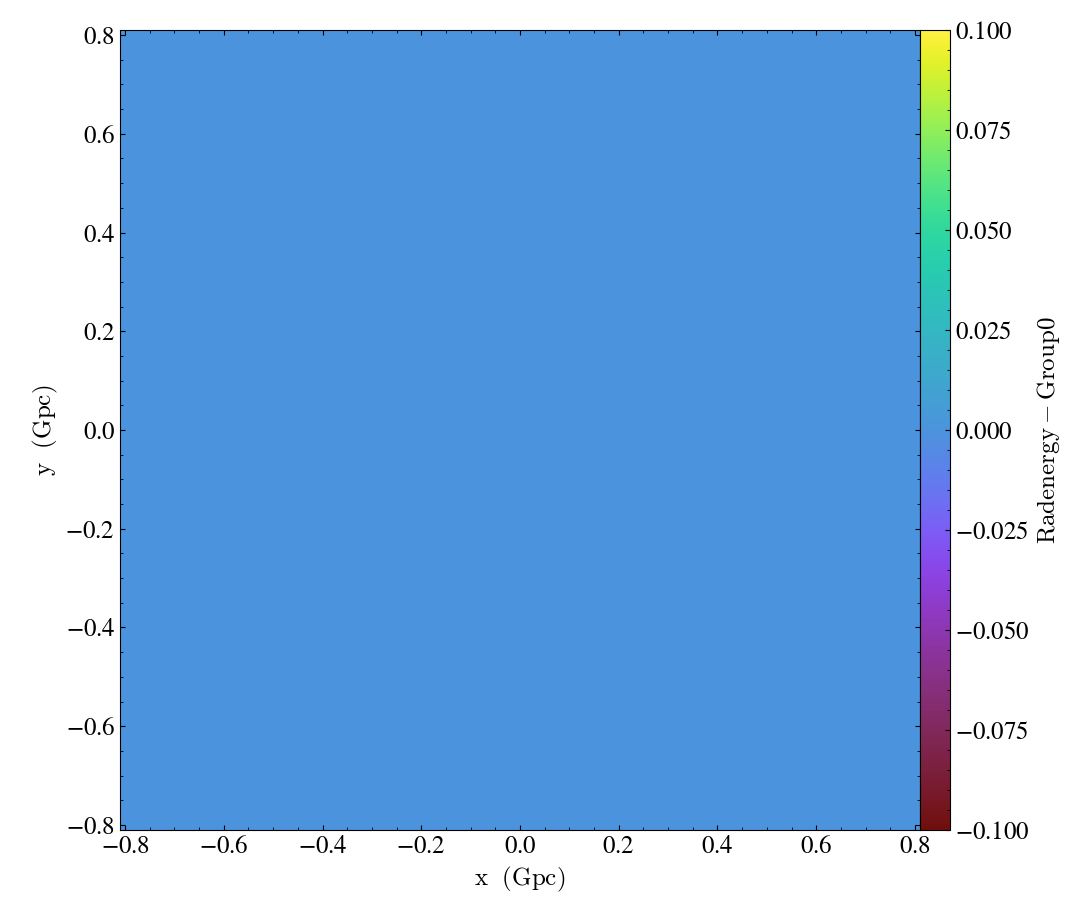

In [105]:
ds_temp = yt.load("./build/plt0020000/")
ds_temp.add_field(("boxlib", "n_e"), function=e_density, units="dimensionless", sampling_type="cell")
ds_temp.add_field(("boxlib", "n_HI"), function=HI_density, units="dimensionless", sampling_type="cell")
ds_temp.add_field(("boxlib", "n_HII"), function=HII_density, units="dimensionless", sampling_type="cell")
ds_temp.add_field(("boxlib", "n_photon"), function=photon_density, units="dimensionless", sampling_type="cell")
ds_temp.add_field(("boxlib", "x_HI"), function=x_HI, units="dimensionless", sampling_type="cell")
yt.SlicePlot(ds_temp, "z", "radEnergy-Group0")

In [90]:
strm = StromgenSphere("./build", ending_number=None, step=1)
# strm.create_radiation_video(vmin=1e-10, vmax=None, cmap="plasma")
# strm.create_scalar_videos(vmin=1e-10, vmax=None, cmap="plasma", redo=True)
# strm.create_density_video()
strm.create_x_HI_video(vmin=0, vmax=1, cmap="plasma", redo=True)

yt : [INFO     ] 2026-03-02 19:51:19,361 Parameters: current_time              = 0.0
yt : [INFO     ] 2026-03-02 19:51:19,502 Parameters: domain_dimensions         = [16 16 16]
yt : [INFO     ] 2026-03-02 19:51:19,549 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2026-03-02 19:51:19,639 Parameters: domain_right_edge         = [5.e+27 5.e+27 5.e+27]


yt : [INFO     ] 2026-03-02 19:51:20,308 Parameters: current_time              = 50000000000000.0
yt : [INFO     ] 2026-03-02 19:51:20,309 Parameters: domain_dimensions         = [16 16 16]
yt : [INFO     ] 2026-03-02 19:51:20,310 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2026-03-02 19:51:20,310 Parameters: domain_right_edge         = [5.e+27 5.e+27 5.e+27]
yt : [INFO     ] 2026-03-02 19:51:20,464 Parameters: current_time              = 100000000000000.0
yt : [INFO     ] 2026-03-02 19:51:20,466 Parameters: domain_dimensions         = [16 16 16]
yt : [INFO     ] 2026-03-02 19:51:20,467 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2026-03-02 19:51:20,468 Parameters: domain_right_edge         = [5.e+27 5.e+27 5.e+27]
yt : [INFO     ] 2026-03-02 19:51:20,624 Parameters: current_time              = 150000000000000.0
yt : [INFO     ] 2026-03-02 19:51:20,626 Parameters: domain_dimensions         = [16 16 16]
yt : [INFO     ] 2026-03-02 19:51:20

Movie saved to ./build/Plots/x_HI_evolution.mp4.mp4


ffmpeg version 8.0 Copyright (c) 2000-2025 the FFmpeg developers
  built with Apple clang version 17.0.0 (clang-1700.3.19.1)
  configuration: --prefix=/opt/homebrew/Cellar/ffmpeg/8.0_2 --enable-shared --enable-pthreads --enable-version3 --cc=clang --host-cflags= --host-ldflags= --enable-ffplay --enable-gnutls --enable-gpl --enable-libaom --enable-libaribb24 --enable-libbluray --enable-libdav1d --enable-libharfbuzz --enable-libjxl --enable-libmp3lame --enable-libopus --enable-librav1e --enable-librist --enable-librubberband --enable-libsnappy --enable-libsrt --enable-libssh --enable-libsvtav1 --enable-libtesseract --enable-libtheora --enable-libvidstab --enable-libvmaf --enable-libvorbis --enable-libvpx --enable-libwebp --enable-libx264 --enable-libx265 --enable-libxml2 --enable-libxvid --enable-lzma --enable-libfontconfig --enable-libfreetype --enable-frei0r --enable-libass --enable-libopencore-amrnb --enable-libopencore-amrwb --enable-libopenjpeg --enable-libspeex --enable-libsoxr --e

In [35]:
strm.snapshot_list[-1].ds.current_time

unyt_quantity(3000., 'code_time')

In [33]:
strm.snapshot_list[-1].ad['n_e'] + strm.snapshot_list[-1].ad['n_HI']

unyt_array([1.e+10, 1.e+10, 1.e+10, ..., 1.e+10, 1.e+10, 1.e+10],
      shape=(32768,), units='dimensionless')